# 08 scenarios rough speed — 不整地・凸凹速度

**対象:** お客様（MPC 設計経験者）との **理論・数式・パラメータ** ディスカッション  
**Part 2/4** — Scenario 06–10

各シナリオは **路面 · 速度 · 勾配 · 実装** を結びつけています。  
理論の前提: [00_theory_grf_mpc_wbc.ipynb](./00_theory_grf_mpc_wbc.ipynb)  
QA 索引: [11_qa_discussion_master.ipynb](./11_qa_discussion_master.ipynb)

```bash
python scripts/scenario_labs.py --list
python scripts/scenario_labs.py --scenario sc06_boxes_s2_gait_fail
```


In [1]:
import sys
from pathlib import Path

# mpc_dog ルートを sys.path に追加
ROOT = Path.cwd()
for p in [ROOT, *ROOT.parents]:
    if (p / "scripts" / "pympc_lab.py").exists():
        ROOT = p
        break
sys.path.insert(0, str(ROOT / "scripts"))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from pympc_lab import (
    TUNING_GUIDE,
    apply_preset,
    compare_runs,
    load_param_study,
    load_preset_yaml,
    plot_friction_cone,
    run_flat_sim,
    run_speed_terrain_sim,
    run_speed_terrain_sim_resilient,
)

from tuning_labs import (
    TUNING_LABS,
    list_labs,
    run_lab,
    run_lab_pair,
    plot_speed_trial_journey,
    plot_param_study_mu,
    load_cached_lab_results,
)

%matplotlib inline
plt.rcParams["figure.figsize"] = (9, 4)
print(f"repo: {ROOT}")

from scenario_labs import (
    SCENARIO_LABS,
    compare_preset_table,
    run_scenario,
    run_scenario_pair,
    scenario_table,
)


repo: /home/takuya/work/mpc_dog


### 不整地（Session 3）

Markdown の `![](../assets/...)` だけでは IDE 内で見えないことがあります。下のセルで **GIF を直接表示** します。

--- s03_boxes ---
  scene: random_boxes
  final_x_m: 6.339
  gif_playback_s: 10.0


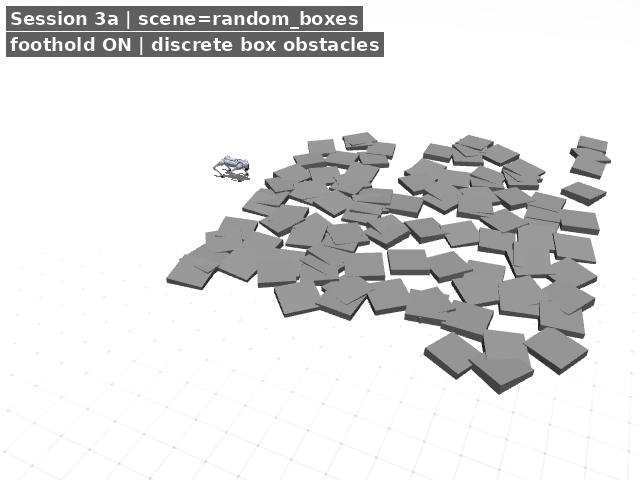

--- s03_perlin ---
  scene: perlin
  final_x_m: 7.968
  gif_playback_s: 10.0


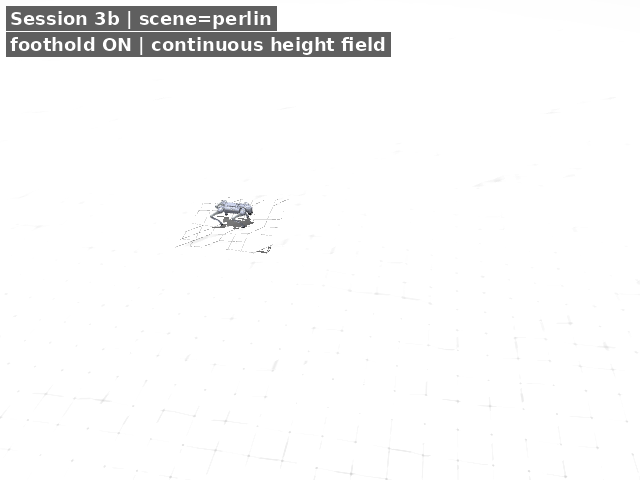

In [2]:
from pathlib import Path
import sys
import json
from IPython.display import Image, display

ROOT = Path.cwd()
for p in [ROOT, *ROOT.parents]:
    if (p / "scripts" / "pympc_lab.py").exists():
        ROOT = p
        break

def show_demo_gifs(tags):
    for tag in tags:
        gif = ROOT / f"docs/pympc_2day/assets/demo_{tag}.gif"
        meta_path = ROOT / f"docs/pympc_2day/assets/demo_{tag}.meta.json"
        print(f"--- {tag} ---")
        if meta_path.is_file():
            m = json.loads(meta_path.read_text())
            for k in ("scene", "final_x_m", "final_dist_m", "gif_playback_s", "falls"):
                if m.get(k) is not None:
                    print(f"  {k}: {m[k]}")
        if gif.is_file():
            display(Image(filename=str(gif)))
        else:
            print("  MISSING:", gif)

show_demo_gifs(["s03_boxes", "s03_perlin"])


## Scenario 06 — 箱地形 × Session2 gait — 地形持ち込み失敗

| 項目 | 内容 |
|------|------|
| **ID** | `sc06_boxes_s2_gait_fail` |
| **分類** | rough / intermediate |
| **路面** | random_boxes（離散段差） |
| **速度** | — kph |
| **勾配** | flat + 箱 |
| **preset** | `session03_rough_boxes` |

### シナリオ

平坦で調整した step_freq=1.6 を箱地形に持ち込むと数秒で転倒。

### 理論（Layer 2–3）

足場 opt ON でも gait が攻めすぎると $s_i(k)$ 周期内に MPC が安全な $F_i$ を確保できない。

$$\min \sum \|x-x^{ref}\|_Q + \|u\|_R \quad \text{s.t. SRB}, \mu, s_i(k)$$

### パラメータ焦点

| `step_freq` | 1.6 → 1.1 | 箱向け保守化 |

**実装:** `simulation_params.scene=random_boxes`, foothold opt ON

### ノウハウ

地形変更 → freq↓ duty↑ が定石。S2 の勝ち gait を S3 に流用しない。

### 議論用 Q&A

Q: 足場最適化 ON なら gait は攻めて良い？
A: 着地点と GRF は別。gait が速いと支持時間不足。


backup: /home/takuya/work/mpc_dog/logs/pympc_sessions/session03_rough_boxes/config.py.bak.20260818T222000Z
applied: session03_rough_boxes -> /home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/config.py
notes: perlin より先に試す。↑ は短く押す（低速前進）。


/home/takuya/work/mpc_dog/.venv/lib/python3.11/site-packages/gymnasium/spaces/box.py:231: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
/home/takuya/work/mpc_dog/.venv/lib/python3.11/site-packages/gymnasium/spaces/box.py:297: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(


field AcadosOcpDims.N has been migrated to AcadosOcpOptions.N_horizon. setting AcadosOcpOptions.N_horizon = N. For future comppatibility, please use AcadosOcpOptions.N_horizon directly.
External functions generated in 86.865 ms.


Templated solver code generated in 1236.940 ms.
rm -f libacados_ocp_solver_ocp_centroidal_model_2bace23d.so
rm -f centroidal_model_constraints/centroidal_model_constr_h_0_fun_jac_uxt_zt.o centroidal_model_constraints/centroidal_model_constr_h_0_fun.o centroidal_model_constraints/centroidal_model_constr_h_fun_jac_uxt_zt.o centroidal_model_constraints/centroidal_model_constr_h_fun.o acados_solver_ocp_centroidal_model_2bace23d.o
cc -fPIC -std=c99   -O2 -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include/acados -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include/blasfeo/include -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include/hpipm/include  -c -o centroidal_model_constraints/centroidal_model_constr_h_0_fun_jac_uxt_zt.o centroidal_model_constraints/centroidal_model_constr_h_0_fun_jac_uxt_zt.c
cc -fPIC -std=c99 

cc -fPIC -std=c99   -O2 -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include/acados -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include/blasfeo/include -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include/hpipm/include  -c -o acados_solver_ocp_centroidal_model_2bace23d.o acados_solver_ocp_centroidal_model_2bace23d.c


...

cc -fPIC -std=c99   -O2 -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include/acados -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include/blasfeo/include -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include/hpipm/include  -c -o acados_solver_ocp_centroidal_model_2bace23d.o acados_solver_ocp_centroidal_model_2bace23d.c


cc -fPIC -std=c99   -O2 -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include/acados -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include/blasfeo/include -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include/hpipm/include  -c -o centroidal_model_model/centroidal_model_expl_ode_fun.o centroidal_model_model/centroidal_model_expl_ode_fun.c
cc -fPIC -std=c99   -O2 -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include/acados -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include/blasfeo/include -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include/hpipm/include  -c -o centroidal_model_model/centroidal_model_expl_vde_forw.o centroidal_model_model/cen

cc -fPIC -std=c99   -O2 -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include/acados -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include/blasfeo/include -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include/hpipm/include  -c -o centroidal_model_model/centroidal_model_expl_vde_adj.o centroidal_model_model/centroidal_model_expl_vde_adj.c
cc -shared centroidal_model_constraints/centroidal_model_constr_h_0_fun_jac_uxt_zt.o centroidal_model_constraints/centroidal_model_constr_h_0_fun.o centroidal_model_constraints/centroidal_model_constr_h_fun_jac_uxt_zt.o centroidal_model_constraints/centroidal_model_constr_h_fun.o acados_solver_ocp_centroidal_model_2bace23d.o centroidal_model_model/centroidal_model_expl_ode_fun.o centroidal_model_model/centroidal_model_expl_vde_forw.o centroidal_model_model/centroidal_model_expl_vde

/home/takuya/work/mpc_dog/.venv/lib/python3.11/site-packages/gymnasium/spaces/box.py:231: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
/home/takuya/work/mpc_dog/.venv/lib/python3.11/site-packages/gymnasium/spaces/box.py:297: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(


/home/takuya/work/mpc_dog/scripts/pympc_lab.py:596: UserWarning: Glyph 31665 (\N{CJK UNIFIED IDEOGRAPH-7BB1}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/home/takuya/work/mpc_dog/scripts/pympc_lab.py:596: UserWarning: Glyph 22320 (\N{CJK UNIFIED IDEOGRAPH-5730}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/home/takuya/work/mpc_dog/scripts/pympc_lab.py:596: UserWarning: Glyph 24418 (\N{CJK UNIFIED IDEOGRAPH-5F62}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/home/takuya/work/mpc_dog/scripts/pympc_lab.py:596: UserWarning: Glyph 25345 (\N{CJK UNIFIED IDEOGRAPH-6301}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/home/takuya/work/mpc_dog/scripts/pympc_lab.py:596: UserWarning: Glyph 12385 (\N{HIRAGANA LETTER TI}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/home/takuya/work/mpc_dog/scripts/pympc_lab.py:596: UserWarning: Glyph 36796 (\N{CJK UNIFIED IDEOGRAPH-8FBC}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/home/takuya/work/

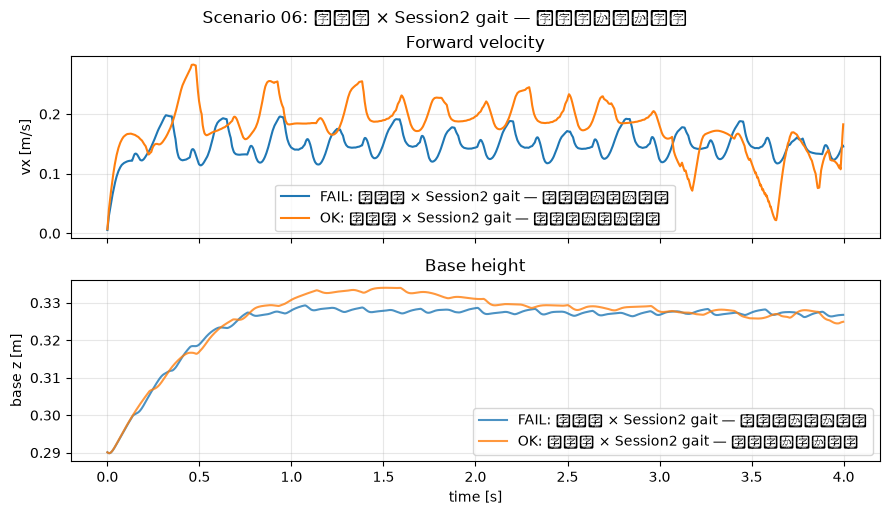

In [3]:
from scenario_labs import run_scenario_pair
from pympc_lab import compare_runs

pair = run_scenario_pair("sc06_boxes_s2_gait_fail")
fig = compare_runs(pair)
plt.suptitle("Scenario 06: 箱地形 × Session2 gait — 地形持ち込み失敗", y=1.02)
plt.show()


## Scenario 07 — Perlin × 高μ — 連続起伏での過信

| 項目 | 内容 |
|------|------|
| **ID** | `sc07_perlin_mu_high` |
| **分類** | rough / intermediate |
| **路面** | perlin（連続起伏） |
| **速度** | — kph |
| **勾配** | flat + 起伏 |
| **preset** | `session03_rough_perlin` |

### シナリオ

boxes より滑らかだが、pitch/roll 変動が連続。μ=0.55 は危険。

### 理論（Layer 2–3）

連続地形では $\mathbf{r}_i$ が常に変化 → $\boldsymbol{\tau}=\mathbf{r}_i\times\mathbf{F}_i$ の摂動大。

$$\mathbf{I}\dot{\boldsymbol{\omega}} = \sum \mathbf{r}_i \times \mathbf{F}_i, \quad |F_{t,i}| \le \mu F_{z,i}$$

### パラメータ焦点

| `mu` | 0.55 → 0.42 | perlin 向け |

**実装:** scene=perlin, `use_foothold_optimization=true`

### ノウハウ

perlin は boxes より μ を下げる（0.42 前後）。

### 議論用 Q&A

Q: boxes と perlin で同じ preset で良い？
A: 同系統だが perlin は μ さらに保守。


backup: /home/takuya/work/mpc_dog/logs/pympc_sessions/session03_rough_perlin/config.py.bak.20260818T222025Z
applied: session03_rough_perlin -> /home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/config.py
notes: 転倒したら env reset 待ち。デモは 20s + 低速前進で十分。
field AcadosOcpDims.N has been migrated to AcadosOcpOptions.N_horizon. setting AcadosOcpOptions.N_horizon = N. For future comppatibility, please use AcadosOcpOptions.N_horizon directly.
External functions generated in 84.665 ms.


Templated solver code generated in 1258.126 ms.
rm -f libacados_ocp_solver_ocp_centroidal_model_2bace23d.so
rm -f centroidal_model_constraints/centroidal_model_constr_h_0_fun_jac_uxt_zt.o centroidal_model_constraints/centroidal_model_constr_h_0_fun.o centroidal_model_constraints/centroidal_model_constr_h_fun_jac_uxt_zt.o centroidal_model_constraints/centroidal_model_constr_h_fun.o acados_solver_ocp_centroidal_model_2bace23d.o
cc -fPIC -std=c99   -O2 -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include/acados -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include/blasfeo/include -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include/hpipm/include  -c -o centroidal_model_constraints/centroidal_model_constr_h_0_fun_jac_uxt_zt.o centroidal_model_constraints/centroidal_model_constr_h_0_fun_jac_uxt_zt.c
cc -fPIC -std=c99 

cc -fPIC -std=c99   -O2 -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include/acados -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include/blasfeo/include -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include/hpipm/include  -c -o acados_solver_ocp_centroidal_model_2bace23d.o acados_solver_ocp_centroidal_model_2bace23d.c


cc -fPIC -std=c99   -O2 -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include/acados -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include/blasfeo/include -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include/hpipm/include  -c -o centroidal_model_model/centroidal_model_expl_ode_fun.o centroidal_model_model/centroidal_model_expl_ode_fun.c
cc -fPIC -std=c99   -O2 -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include/acados -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include/blasfeo/include -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include/hpipm/include  -c -o centroidal_model_model/centroidal_model_expl_vde_forw.o centroidal_model_model/cen

cc -fPIC -std=c99   -O2 -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include/acados -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include/blasfeo/include -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include/hpipm/include  -c -o centroidal_model_model/centroidal_model_expl_vde_adj.o centroidal_model_model/centroidal_model_expl_vde_adj.c
cc -shared centroidal_model_constraints/centroidal_model_constr_h_0_fun_jac_uxt_zt.o centroidal_model_constraints/centroidal_model_constr_h_0_fun.o centroidal_model_constraints/centroidal_model_constr_h_fun_jac_uxt_zt.o centroidal_model_constraints/centroidal_model_constr_h_fun.o acados_solver_ocp_centroidal_model_2bace23d.o centroidal_model_model/centroidal_model_expl_ode_fun.o centroidal_model_model/centroidal_model_expl_vde_forw.o centroidal_model_model/centroidal_model_expl_vde

...

cc -fPIC -std=c99   -O2 -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include/acados -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include/blasfeo/include -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include/hpipm/include  -c -o centroidal_model_constraints/centroidal_model_constr_h_fun.o centroidal_model_constraints/centroidal_model_constr_h_fun.c
cc -fPIC -std=c99   -O2 -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include/acados -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include/blasfeo/include -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include/hpipm/include  -c -o acados_solver_ocp_centroidal_model_2bace23d.o acados_solver_ocp_centro

cc -fPIC -std=c99   -O2 -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include/acados -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include/blasfeo/include -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include/hpipm/include  -c -o centroidal_model_model/centroidal_model_expl_ode_fun.o centroidal_model_model/centroidal_model_expl_ode_fun.c
cc -fPIC -std=c99   -O2 -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include/acados -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include/blasfeo/include -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include/hpipm/include  -c -o centroidal_model_model/centroidal_model_expl_vde_forw.o centroidal_model_model/cen

cc -fPIC -std=c99   -O2 -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include/acados -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include/blasfeo/include -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include/hpipm/include  -c -o centroidal_model_model/centroidal_model_expl_vde_adj.o centroidal_model_model/centroidal_model_expl_vde_adj.c
cc -shared centroidal_model_constraints/centroidal_model_constr_h_0_fun_jac_uxt_zt.o centroidal_model_constraints/centroidal_model_constr_h_0_fun.o centroidal_model_constraints/centroidal_model_constr_h_fun_jac_uxt_zt.o centroidal_model_constraints/centroidal_model_constr_h_fun.o acados_solver_ocp_centroidal_model_2bace23d.o centroidal_model_model/centroidal_model_expl_ode_fun.o centroidal_model_model/centroidal_model_expl_vde_forw.o centroidal_model_model/centroidal_model_expl_vde

/home/takuya/work/mpc_dog/.venv/lib/python3.11/site-packages/gymnasium/spaces/box.py:231: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
/home/takuya/work/mpc_dog/.venv/lib/python3.11/site-packages/gymnasium/spaces/box.py:297: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(


/home/takuya/work/mpc_dog/scripts/pympc_lab.py:596: UserWarning: Glyph 39640 (\N{CJK UNIFIED IDEOGRAPH-9AD8}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/home/takuya/work/mpc_dog/scripts/pympc_lab.py:596: UserWarning: Glyph 36899 (\N{CJK UNIFIED IDEOGRAPH-9023}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/home/takuya/work/mpc_dog/scripts/pympc_lab.py:596: UserWarning: Glyph 32154 (\N{CJK UNIFIED IDEOGRAPH-7D9A}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/home/takuya/work/mpc_dog/scripts/pympc_lab.py:596: UserWarning: Glyph 36215 (\N{CJK UNIFIED IDEOGRAPH-8D77}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/home/takuya/work/mpc_dog/scripts/pympc_lab.py:596: UserWarning: Glyph 20239 (\N{CJK UNIFIED IDEOGRAPH-4F0F}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/home/takuya/work/mpc_dog/scripts/pympc_lab.py:596: UserWarning: Glyph 12391 (\N{HIRAGANA LETTER DE}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/home/takuya/work/

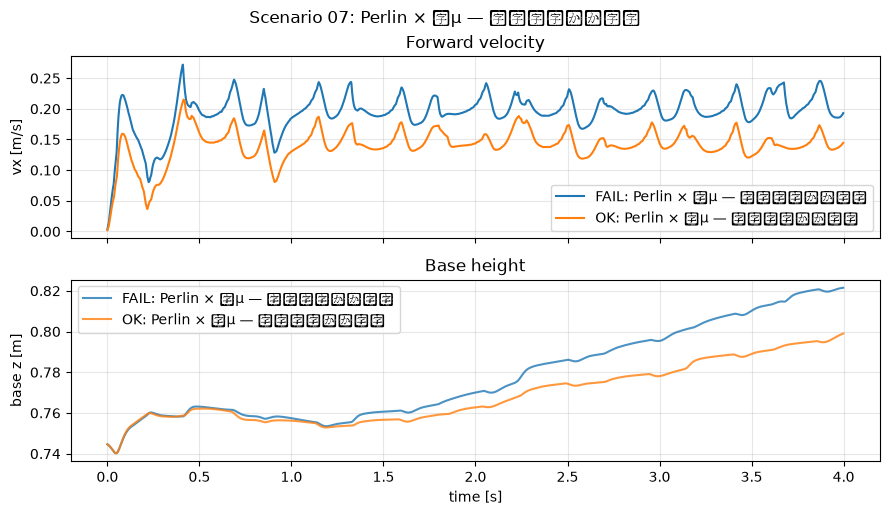

In [4]:
from scenario_labs import run_scenario_pair
from pympc_lab import compare_runs

pair = run_scenario_pair("sc07_perlin_mu_high")
fig = compare_runs(pair)
plt.suptitle("Scenario 07: Perlin × 高μ — 連続起伏での過信", y=1.02)
plt.show()


## Scenario 08 — 足場 opt OFF — 地形モデル不一致の切り分け

| 項目 | 内容 |
|------|------|
| **ID** | `sc08_perlin_foothold_off` |
| **分類** | rough / intermediate |
| **路面** | perlin |
| **速度** | — kph |
| **勾配** | flat + 起伏 |
| **preset** | `session03_rough_perlin` |

### シナリオ

不整地で変な足位置 → まず foothold opt OFF で baseline 比較。

### 理論（Layer 2–3）

Layer 2 の foothold 変数が地形推定 $\hat{h}(x,y)$ に依存。不一致で変な $F_i$。

$$u_k^* = \arg\min J(x,u) \quad \text{（foothold ON: } u \text{ に着地も含む）}$$

### パラメータ焦点

| `use_foothold_optimization` | ON vs OFF | 切り分け |

**実装:** `mpc_params.use_foothold_optimization`

### ノウハウ

OFF で安定→地形/推定問題。OFF でも転倒→gait/μ 問題。

### 議論用 Q&A

Q: 本番は常に ON？
A: 推定が信頼できるなら ON。デバッグ・平坦は OFF。


backup: /home/takuya/work/mpc_dog/logs/pympc_sessions/session03_rough_perlin/config.py.bak.20260818T222049Z
applied: session03_rough_perlin -> /home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/config.py
notes: 転倒したら env reset 待ち。デモは 20s + 低速前進で十分。
field AcadosOcpDims.N has been migrated to AcadosOcpOptions.N_horizon. setting AcadosOcpOptions.N_horizon = N. For future comppatibility, please use AcadosOcpOptions.N_horizon directly.
External functions generated in 83.741 ms.


Templated solver code generated in 1221.427 ms.
rm -f libacados_ocp_solver_ocp_centroidal_model_5432c2dd.so
rm -f centroidal_model_constraints/centroidal_model_constr_h_0_fun_jac_uxt_zt.o centroidal_model_constraints/centroidal_model_constr_h_0_fun.o centroidal_model_constraints/centroidal_model_constr_h_fun_jac_uxt_zt.o centroidal_model_constraints/centroidal_model_constr_h_fun.o acados_solver_ocp_centroidal_model_5432c2dd.o
cc -fPIC -std=c99   -O2 -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include/acados -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include/blasfeo/include -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include/hpipm/include  -c -o centroidal_model_constraints/centroidal_model_constr_h_0_fun_jac_uxt_zt.o centroidal_model_constraints/centroidal_model_constr_h_0_fun_jac_uxt_zt.c
cc -fPIC -std=c99 

cc -fPIC -std=c99   -O2 -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include/acados -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include/blasfeo/include -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include/hpipm/include  -c -o acados_solver_ocp_centroidal_model_5432c2dd.o acados_solver_ocp_centroidal_model_5432c2dd.c


cc -fPIC -std=c99   -O2 -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include/acados -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include/blasfeo/include -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include/hpipm/include  -c -o centroidal_model_model/centroidal_model_expl_ode_fun.o centroidal_model_model/centroidal_model_expl_ode_fun.c
cc -fPIC -std=c99   -O2 -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include/acados -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include/blasfeo/include -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include/hpipm/include  -c -o centroidal_model_model/centroidal_model_expl_vde_forw.o centroidal_model_model/cen

cc -fPIC -std=c99   -O2 -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include/acados -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include/blasfeo/include -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include/hpipm/include  -c -o centroidal_model_model/centroidal_model_expl_vde_adj.o centroidal_model_model/centroidal_model_expl_vde_adj.c
cc -shared centroidal_model_constraints/centroidal_model_constr_h_0_fun_jac_uxt_zt.o centroidal_model_constraints/centroidal_model_constr_h_0_fun.o centroidal_model_constraints/centroidal_model_constr_h_fun_jac_uxt_zt.o centroidal_model_constraints/centroidal_model_constr_h_fun.o acados_solver_ocp_centroidal_model_5432c2dd.o centroidal_model_model/centroidal_model_expl_ode_fun.o centroidal_model_model/centroidal_model_expl_vde_forw.o centroidal_model_model/centroidal_model_expl_vde

...

cc -fPIC -std=c99   -O2 -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include/acados -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include/blasfeo/include -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include/hpipm/include  -c -o acados_solver_ocp_centroidal_model_2bace23d.o acados_solver_ocp_centroidal_model_2bace23d.c


cc -fPIC -std=c99   -O2 -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include/acados -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include/blasfeo/include -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include/hpipm/include  -c -o centroidal_model_model/centroidal_model_expl_ode_fun.o centroidal_model_model/centroidal_model_expl_ode_fun.c
cc -fPIC -std=c99   -O2 -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include/acados -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include/blasfeo/include -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include/hpipm/include  -c -o centroidal_model_model/centroidal_model_expl_vde_forw.o centroidal_model_model/cen

cc -fPIC -std=c99   -O2 -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include/acados -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include/blasfeo/include -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include/hpipm/include  -c -o centroidal_model_model/centroidal_model_expl_vde_adj.o centroidal_model_model/centroidal_model_expl_vde_adj.c
cc -shared centroidal_model_constraints/centroidal_model_constr_h_0_fun_jac_uxt_zt.o centroidal_model_constraints/centroidal_model_constr_h_0_fun.o centroidal_model_constraints/centroidal_model_constr_h_fun_jac_uxt_zt.o centroidal_model_constraints/centroidal_model_constr_h_fun.o acados_solver_ocp_centroidal_model_2bace23d.o centroidal_model_model/centroidal_model_expl_ode_fun.o centroidal_model_model/centroidal_model_expl_vde_forw.o centroidal_model_model/centroidal_model_expl_vde

/home/takuya/work/mpc_dog/.venv/lib/python3.11/site-packages/gymnasium/spaces/box.py:231: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
/home/takuya/work/mpc_dog/.venv/lib/python3.11/site-packages/gymnasium/spaces/box.py:297: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(


/home/takuya/work/mpc_dog/scripts/pympc_lab.py:596: UserWarning: Glyph 36275 (\N{CJK UNIFIED IDEOGRAPH-8DB3}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/home/takuya/work/mpc_dog/scripts/pympc_lab.py:596: UserWarning: Glyph 22580 (\N{CJK UNIFIED IDEOGRAPH-5834}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/home/takuya/work/mpc_dog/scripts/pympc_lab.py:596: UserWarning: Glyph 22320 (\N{CJK UNIFIED IDEOGRAPH-5730}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/home/takuya/work/mpc_dog/scripts/pympc_lab.py:596: UserWarning: Glyph 24418 (\N{CJK UNIFIED IDEOGRAPH-5F62}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/home/takuya/work/mpc_dog/scripts/pympc_lab.py:596: UserWarning: Glyph 12514 (\N{KATAKANA LETTER MO}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/home/takuya/work/mpc_dog/scripts/pympc_lab.py:596: UserWarning: Glyph 12487 (\N{KATAKANA LETTER DE}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/home/takuya/work/mpc_dog/

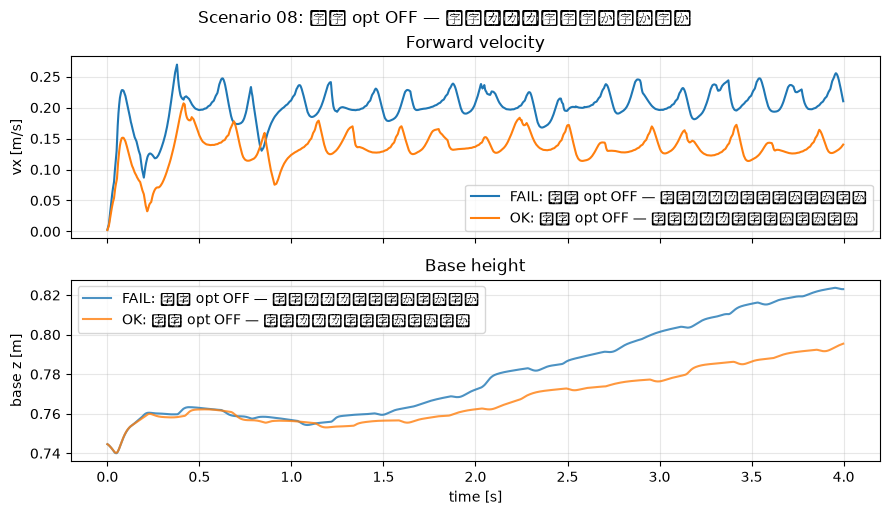

In [5]:
from scenario_labs import run_scenario_pair
from pympc_lab import compare_runs

pair = run_scenario_pair("sc08_perlin_foothold_off")
fig = compare_runs(pair)
plt.suptitle("Scenario 08: 足場 opt OFF — 地形モデル不一致の切り分け", y=1.02)
plt.show()


## Scenario 09 — 凸凹平坦 3 kph — 速度を下げた no-fall

| 項目 | 内容 |
|------|------|
| **ID** | `sc09_bumpy_3kph` |
| **分類** | speed / intermediate |
| **路面** | bumpy_flat（Perlin heightfield） |
| **速度** | 3.0 kph |
| **勾配** | flat + 凸凹 |
| **preset** | `session04_speed_bumpy_base` |

### シナリオ

5 kph が厳しいとき、3 kph + 長 ramp で no-fall 成功域を確認。

### 理論（Layer 2–3）

指令 $v^{ref}(t)$ ランプ: $v^{ref}(t)=v_{target}\min(t/T_{ramp},1)$。低速度は $F_{ix}$ 要求↓。

$$m a_x \approx \sum F_{ix}, \quad v^{ref} \downarrow \Rightarrow |F_{ix}| \downarrow$$

### パラメータ焦点

| `target_speed_kph` | 3.0 | `speed_ramp_s` | 15 |

**実装:** `run_speed_terrain_sim` — min_distance 10 m で短時間検証

### ノウハウ

速度限界の探索: 3→4→5 kph と段階的に。

### 議論用 Q&A

Q: 3 kph 成功が 5 kph 成功の必要条件？
A: 十分条件ではないが、失敗なら 5 kph は早すぎ。


In [6]:
from scenario_labs import run_scenario

r = run_scenario("sc09_bumpy_3kph")
res = r.get("result", {})
for k in ("distance_m", "mean_kph", "success", "terminated", "falls", "mean_vx", "max_roll_deg"):
    if k in res:
        print(f"{k}: {res[k]}")


backup: /home/takuya/work/mpc_dog/logs/pympc_sessions/session04_speed_bumpy_base/config.py.bak.20260818T222113Z
applied: session04_speed_bumpy_base -> /home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/config.py
notes: Use scripts/run_speed_terrain_benchmark.py to tune per-terrain scene + speed.
Custom scenes: bumpy_flat, bumpy_uphill, bumpy_downhill (workshop_terrain.py).
backup: /home/takuya/work/mpc_dog/logs/pympc_sessions/session04_speed_bumpy_base/config.py.bak.20260818T222113Z
applied: session04_speed_bumpy_base -> /home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/config.py
notes: Use scripts/run_speed_terrain_benchmark.py to tune per-terrain scene + speed.
Custom scenes: bumpy_flat, bumpy_uphill, bumpy_downhill (workshop_terrain.py).
field AcadosOcpDims.N has been migrated to AcadosOcpOptions.N_horizon. setting AcadosOcpOptions.N_horizon = N. For future comppatibility, please use AcadosOcpOptions.N_horizon directly.


External functions generated in 85.882 ms.


Templated solver code generated in 1256.679 ms.
rm -f libacados_ocp_solver_ocp_centroidal_model_2bace23d.so
rm -f centroidal_model_constraints/centroidal_model_constr_h_0_fun_jac_uxt_zt.o centroidal_model_constraints/centroidal_model_constr_h_0_fun.o centroidal_model_constraints/centroidal_model_constr_h_fun_jac_uxt_zt.o centroidal_model_constraints/centroidal_model_constr_h_fun.o acados_solver_ocp_centroidal_model_2bace23d.o
cc -fPIC -std=c99   -O2 -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include/acados -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include/blasfeo/include -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include/hpipm/include  -c -o centroidal_model_constraints/centroidal_model_constr_h_0_fun_jac_uxt_zt.o centroidal_model_constraints/centroidal_model_constr_h_0_fun_jac_uxt_zt.c
cc -fPIC -std=c99 

cc -fPIC -std=c99   -O2 -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include/acados -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include/blasfeo/include -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include/hpipm/include  -c -o acados_solver_ocp_centroidal_model_2bace23d.o acados_solver_ocp_centroidal_model_2bace23d.c


cc -fPIC -std=c99   -O2 -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include/acados -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include/blasfeo/include -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include/hpipm/include  -c -o centroidal_model_model/centroidal_model_expl_ode_fun.o centroidal_model_model/centroidal_model_expl_ode_fun.c
cc -fPIC -std=c99   -O2 -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include/acados -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include/blasfeo/include -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include/hpipm/include  -c -o centroidal_model_model/centroidal_model_expl_vde_forw.o centroidal_model_model/cen

cc -fPIC -std=c99   -O2 -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include/acados -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include/blasfeo/include -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include/hpipm/include  -c -o centroidal_model_model/centroidal_model_expl_vde_adj.o centroidal_model_model/centroidal_model_expl_vde_adj.c
cc -shared centroidal_model_constraints/centroidal_model_constr_h_0_fun_jac_uxt_zt.o centroidal_model_constraints/centroidal_model_constr_h_0_fun.o centroidal_model_constraints/centroidal_model_constr_h_fun_jac_uxt_zt.o centroidal_model_constraints/centroidal_model_constr_h_fun.o acados_solver_ocp_centroidal_model_2bace23d.o centroidal_model_model/centroidal_model_expl_ode_fun.o centroidal_model_model/centroidal_model_expl_vde_forw.o centroidal_model_model/centroidal_model_expl_vde

Build completed in 4668.383 ms.
acados was compiled without OpenMP.


/home/takuya/work/mpc_dog/.venv/lib/python3.11/site-packages/gymnasium/spaces/box.py:231: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
/home/takuya/work/mpc_dog/.venv/lib/python3.11/site-packages/gymnasium/spaces/box.py:297: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(


distance_m: 5.2078435779857655
mean_kph: 1.1110724713019278
success: False
terminated: True
mean_vx: 0.30863124202831327
max_roll_deg: 53.06829767503307


## Scenario 10 — 凸凹 5 kph no-fall — 距離 ~4 m で失敗

| 項目 | 内容 |
|------|------|
| **ID** | `sc10_bumpy_5kph_no_fall_fail` |
| **分類** | speed / advanced |
| **路面** | bumpy_flat |
| **速度** | 5.0 kph |
| **勾配** | flat + 凸凹 |
| **preset** | `session04_speed_bumpy_base` |

### シナリオ

Session 4 の最初の壁。5 kph + 短 ramp → 数 m で転倒。

### 理論（Layer 2–3）

凸凹で $F_{iz}^{min}$ 違反・姿勢摂動。$Q$ で roll/pitch 追従と $R$ で $\|u\|$ のトレードオフ。

$$\min \sum \|x_k-x_k^{ref}\|_Q + \|u_k\|_R \quad \text{s.t. } f_{SRB}, \mu, F_z$$

### パラメータ焦点

| `speed_ramp_s` | 12 → 18 | `step_freq` | 1.35 → 1.20 |

**実装:** `run_speed_terrain_sim` — success は 8 m 到達の緩和版

### ノウハウ

no-fall 不可でも resilient で学習→パラメータ探索に使う。

### 議論用 Q&A

Q: no-fall 20 m は必須？
A: 本ワークショップでは resilient 20 m を実用目標に。


backup: /home/takuya/work/mpc_dog/logs/pympc_sessions/session04_speed_bumpy_base/config.py.bak.20260818T222143Z
applied: session04_speed_bumpy_base -> /home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/config.py
notes: Use scripts/run_speed_terrain_benchmark.py to tune per-terrain scene + speed.
Custom scenes: bumpy_flat, bumpy_uphill, bumpy_downhill (workshop_terrain.py).
backup: /home/takuya/work/mpc_dog/logs/pympc_sessions/session04_speed_bumpy_base/config.py.bak.20260818T222143Z
applied: session04_speed_bumpy_base -> /home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/config.py
notes: Use scripts/run_speed_terrain_benchmark.py to tune per-terrain scene + speed.
Custom scenes: bumpy_flat, bumpy_uphill, bumpy_downhill (workshop_terrain.py).
field AcadosOcpDims.N has been migrated to AcadosOcpOptions.N_horizon. setting AcadosOcpOptions.N_horizon = N. For future comppatibility, please use AcadosOcpOptions.N_horizon directly.


External functions generated in 86.915 ms.


Templated solver code generated in 1270.969 ms.
rm -f libacados_ocp_solver_ocp_centroidal_model_2bace23d.so
rm -f centroidal_model_constraints/centroidal_model_constr_h_0_fun_jac_uxt_zt.o centroidal_model_constraints/centroidal_model_constr_h_0_fun.o centroidal_model_constraints/centroidal_model_constr_h_fun_jac_uxt_zt.o centroidal_model_constraints/centroidal_model_constr_h_fun.o acados_solver_ocp_centroidal_model_2bace23d.o
cc -fPIC -std=c99   -O2 -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include/acados -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include/blasfeo/include -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include/hpipm/include  -c -o centroidal_model_constraints/centroidal_model_constr_h_0_fun_jac_uxt_zt.o centroidal_model_constraints/centroidal_model_constr_h_0_fun_jac_uxt_zt.c
cc -fPIC -std=c99 

cc -fPIC -std=c99   -O2 -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include/acados -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include/blasfeo/include -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include/hpipm/include  -c -o acados_solver_ocp_centroidal_model_2bace23d.o acados_solver_ocp_centroidal_model_2bace23d.c


cc -fPIC -std=c99   -O2 -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include/acados -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include/blasfeo/include -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include/hpipm/include  -c -o centroidal_model_model/centroidal_model_expl_ode_fun.o centroidal_model_model/centroidal_model_expl_ode_fun.c
cc -fPIC -std=c99   -O2 -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include/acados -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include/blasfeo/include -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include/hpipm/include  -c -o centroidal_model_model/centroidal_model_expl_vde_forw.o centroidal_model_model/cen

...

cc -fPIC -std=c99   -O2 -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include/acados -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include/blasfeo/include -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include/hpipm/include  -c -o centroidal_model_model/centroidal_model_expl_ode_fun.o centroidal_model_model/centroidal_model_expl_ode_fun.c
cc -fPIC -std=c99   -O2 -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include/acados -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include/blasfeo/include -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include/hpipm/include  -c -o centroidal_model_model/centroidal_model_expl_vde_forw.o centroidal_model_model/cen

cc -fPIC -std=c99   -O2 -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include/acados -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include/blasfeo/include -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include/hpipm/include  -c -o centroidal_model_model/centroidal_model_expl_vde_adj.o centroidal_model_model/centroidal_model_expl_vde_adj.c
cc -shared centroidal_model_constraints/centroidal_model_constr_h_0_fun_jac_uxt_zt.o centroidal_model_constraints/centroidal_model_constr_h_0_fun.o centroidal_model_constraints/centroidal_model_constr_h_fun_jac_uxt_zt.o centroidal_model_constraints/centroidal_model_constr_h_fun.o acados_solver_ocp_centroidal_model_2bace23d.o centroidal_model_model/centroidal_model_expl_ode_fun.o centroidal_model_model/centroidal_model_expl_vde_forw.o centroidal_model_model/centroidal_model_expl_vde

Build completed in 4602.249 ms.
acados was compiled without OpenMP.


/home/takuya/work/mpc_dog/.venv/lib/python3.11/site-packages/gymnasium/spaces/box.py:231: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
/home/takuya/work/mpc_dog/.venv/lib/python3.11/site-packages/gymnasium/spaces/box.py:297: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(


/home/takuya/work/mpc_dog/scripts/pympc_lab.py:596: UserWarning: Glyph 20984 (\N{CJK UNIFIED IDEOGRAPH-51F8}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/home/takuya/work/mpc_dog/scripts/pympc_lab.py:596: UserWarning: Glyph 20985 (\N{CJK UNIFIED IDEOGRAPH-51F9}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/home/takuya/work/mpc_dog/scripts/pympc_lab.py:596: UserWarning: Glyph 36317 (\N{CJK UNIFIED IDEOGRAPH-8DDD}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/home/takuya/work/mpc_dog/scripts/pympc_lab.py:596: UserWarning: Glyph 38626 (\N{CJK UNIFIED IDEOGRAPH-96E2}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/home/takuya/work/mpc_dog/scripts/pympc_lab.py:596: UserWarning: Glyph 12391 (\N{HIRAGANA LETTER DE}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/home/takuya/work/mpc_dog/scripts/pympc_lab.py:596: UserWarning: Glyph 22833 (\N{CJK UNIFIED IDEOGRAPH-5931}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/home/takuya/work/

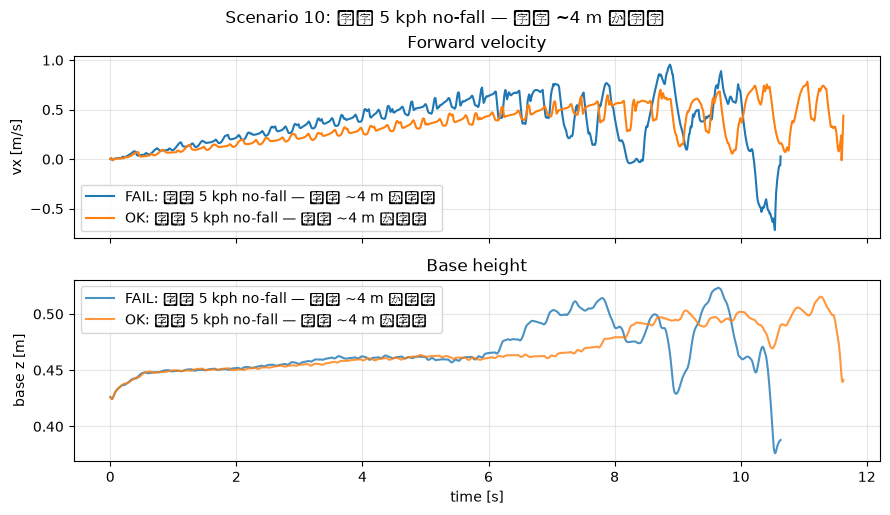

In [7]:
from scenario_labs import run_scenario_pair
from pympc_lab import compare_runs

pair = run_scenario_pair("sc10_bumpy_5kph_no_fall_fail")
fig = compare_runs(pair)
plt.suptitle("Scenario 10: 凸凹 5 kph no-fall — 距離 ~4 m で失敗", y=1.02)
plt.show()


---

## Part 2 チェックリスト

- [ ] Scenario 06–10 それぞれ **数式 → パラメータ → 結果** を説明できる  
- [ ] fail / OK の差が **摩擦円錐 · gait · 指令 ramp** のどれか特定できる  
- [ ] `configs/pympc_presets/` の YAML と対応づけられる  

**次:** [09_scenarios_slope_ramp.ipynb](./09_scenarios_slope_ramp.ipynb)
